In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Rescaling, Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# https://www.cs.toronto.edu/~kriz/cifar.html
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
x_train.shape


(50000, 32, 32, 3)

In [ ]:
img_height = 32
img_width = 32
colors = 3

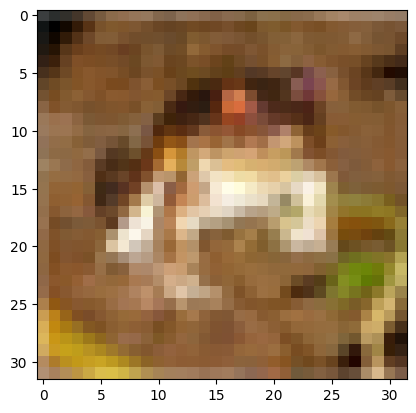

In [ ]:
plt.imshow(x_train[0]);

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [ ]:
y_cat_train = to_categorical(y_train)
y_cat_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
y_cat_test = to_categorical(y_test)

In [ ]:
x_train.max()

255

In [ ]:
model = Sequential()

model.add(Rescaling(1.0/255, input_shape=(img_height,img_width,colors)))

model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPool2D())

model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 32, 32, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 6, 6, 64)          0

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [ ]:
model.fit(x=x_train, y=y_cat_train,
          batch_size=64,
          epochs=20,
          callbacks=[early_stop],
          validation_data=(x_test,y_cat_test))

Epoch 1/20
782/782 [==============================] - 15s 6ms/step - loss: 1.5247 - accuracy: 0.4502 - val_loss: 1.2949 - val_accuracy: 0.5401
Epoch 2/20
782/782 [==============================] - 4s 6ms/step - loss: 1.1907 - accuracy: 0.5787 - val_loss: 1.0682 - val_accuracy: 0.6278
Epoch 3/20
782/782 [==============================] - 4s 5ms/step - loss: 1.0527 - accuracy: 0.6287 - val_loss: 0.9998 - val_accuracy: 0.6496
Epoch 4/20
782/782 [==============================] - 4s 5ms/step - loss: 0.9754 - accuracy: 0.6596 - val_loss: 0.9226 - val_accuracy: 0.6815
Epoch 5/20
782/782 [==============================] - 4s 5ms/step - loss: 0.9056 - accuracy: 0.6844 - val_loss: 0.8969 - val_accuracy: 0.6919
Epoch 6/20
782/782 [==============================] - 4s 5ms/step - loss: 0.8497 - accuracy: 0.7010 - val_loss: 0.8726 - val_accuracy: 0.6973
Epoch 7/20
782/782 [==============================] - 4s 5ms/step - loss: 0.7982 - accuracy: 0.7242 - val_loss: 0.8389 - val_accuracy: 0.7133
Epoch

In [ ]:
losses = pd.DataFrame(model.history.history)

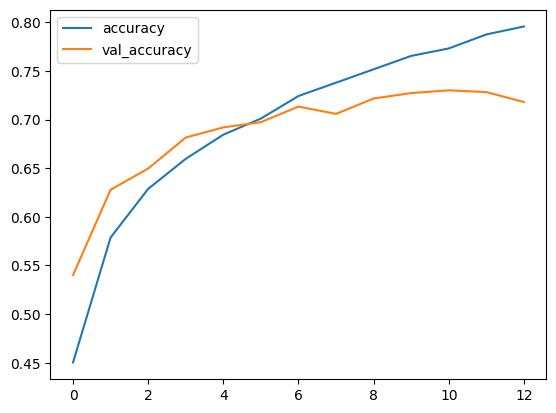

In [ ]:
losses[['accuracy','val_accuracy']].plot();

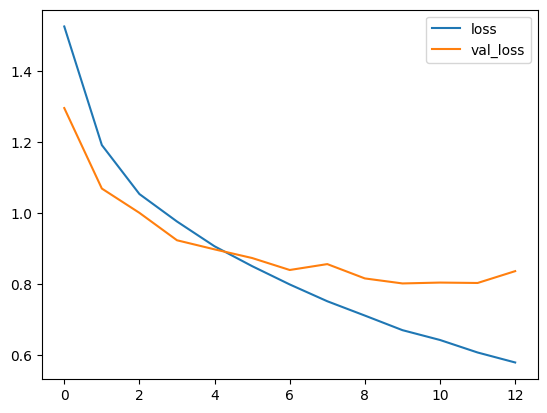

In [ ]:
losses[['loss','val_loss']].plot();

In [ ]:
model.metrics_names

['loss', 'accuracy']

In [ ]:
model.evaluate(x_test, y_cat_test, verbose = 0)

[0.8356362581253052, 0.7179999947547913]

In [ ]:
predictions = np.argmax(model.predict(x_test), axis=-1)

313/313 [==============================] - 1s 2ms/step


In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77      1000
           1       0.85      0.83      0.84      1000
           2       0.68      0.58      0.63      1000
           3       0.53      0.47      0.50      1000
           4       0.67      0.69      0.68      1000
           5       0.50      0.75      0.60      1000
           6       0.89      0.70      0.78      1000
           7       0.80      0.74      0.77      1000
           8       0.83      0.82      0.82      1000
           9       0.78      0.83      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



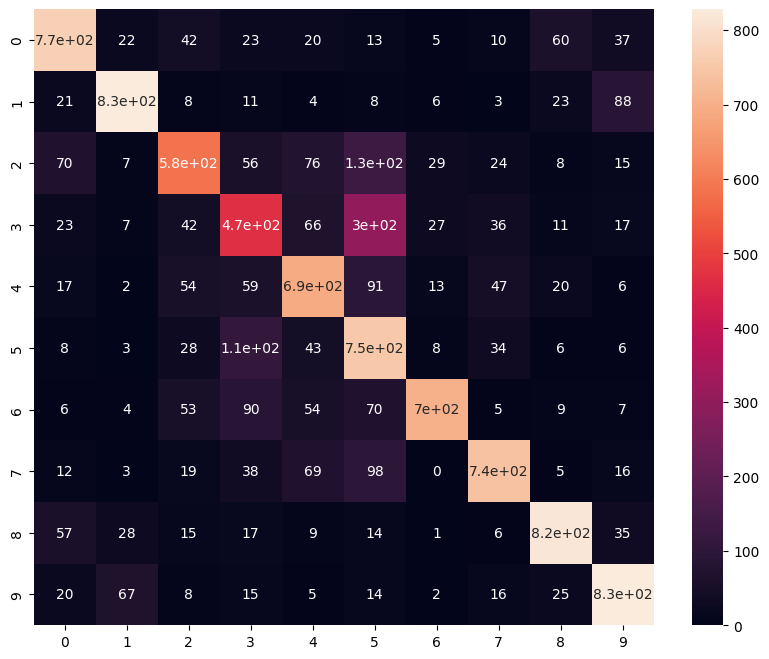

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test,predictions),annot=True);

In [ ]:
my_image = x_test[1000]

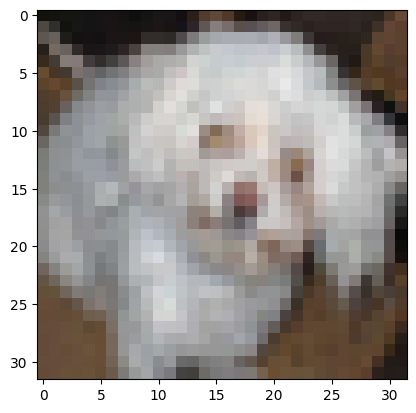

In [ ]:
plt.imshow(my_image);

In [ ]:
my_image = my_image.reshape(1, img_height, img_width, colors)

In [ ]:
prediction = model.predict(my_image)

1/1 [==============================] - 0s 132ms/step


In [ ]:
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print(f'This image belongs to {class_names[predicted_class]} with a {np.floor(confidence*1e4)/100}% of condifence.')

This image belongs to dog with a 97.36% of condifence.
